In [2]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# import data
df = pd.read_csv(r'tele_churn.csv')

In [38]:
# intro to data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df['TotalCharges'].value_counts()
df['TotalCharges'].isna().sum()


np.int64(0)

In [5]:
# replace the empty space with NaN
import numpy as np
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan)

# change dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [6]:
# confrim dtype
df['TotalCharges'].dtype

dtype('float64')

In [7]:
# check the tenure
df.loc[df['TotalCharges'].isna() , ['TotalCharges','tenure']]

,TotalCharges,tenure
488,NaN,0
753,NaN,0
936,NaN,0
1082,NaN,0
1340,NaN,0
3331,NaN,0
3826,NaN,0
4380,NaN,0
5218,NaN,0
6670,NaN,0


Now fill the nan value of total charges with 0 beacuse there tenure is 0 it means they are new user yet they donot have any bil


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
# confrim
df['TotalCharges'].isna().sum()

np.int64(0)

In [12]:
# Get a over View of churn customers
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
# get a percentage
total_counts = len( df['Churn'])
total_counts
no_count_No= len(df[df['Churn']=='No'])
no_count_No
no_count_Yes = len(df[df['Churn']=="Yes"])
# calculate

# no
no_percentage =( no_count_No/total_counts) * 100

yes_percentage =(no_count_Yes / total_counts) *100
print(f'No:     {no_percentage} \n Yes:     {yes_percentage}')

No:     73.4630129206304 
 Yes:     26.536987079369588


In [14]:
# simple
df['Churn'].value_counts(normalize=True)* 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

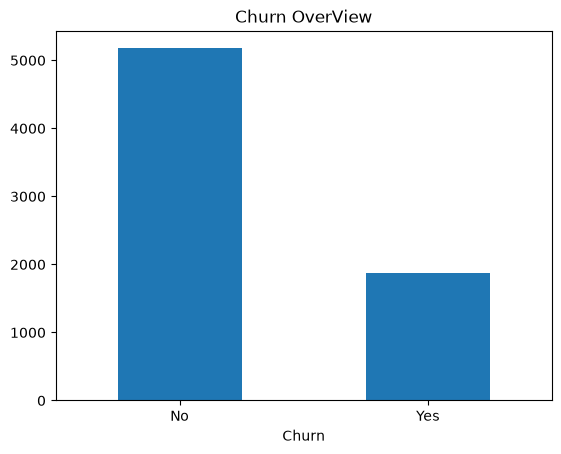

In [15]:
# make a graph
plt.title('Churn OverView')
df['Churn'].value_counts().plot(kind = 'bar')
plt.xticks(rotation =0)

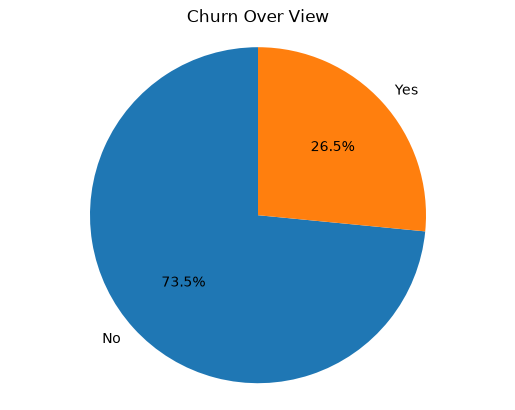

In [16]:
plt.title('Churn Over View')
churn_counts = df['Churn'].value_counts()
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.axis('equal')
plt.show() 

**Demographic analysis**
Now check the is any affect of customer relation ship churn

In [20]:
# seniorCitizen vs CHurn
# partenr or Depedents vs churn

df.groupby('SeniorCitizen')['Churn'].value_counts()

SeniorCitizen  Churn
0              No       4508
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64

<Axes: title={'center': 'SeniorCitizen  VS Churn'}, xlabel='SeniorCitizen', ylabel='count'>

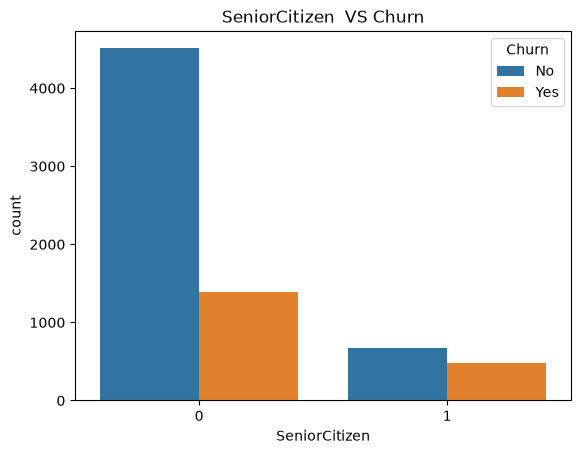

In [21]:
plt.title('SeniorCitizen  VS Churn')
sb.countplot(x=df['SeniorCitizen'] ,hue = df['Churn'])

In [22]:
# partenr vs churn
df.groupby(['Partner'])['Churn'].value_counts()

Partner  Churn
No       No       2441
         Yes      1200
Yes      No       2733
         Yes       669
Name: count, dtype: int64

<Axes: title={'center': ' Partner Vs Churn'}, xlabel='Partner', ylabel='count'>

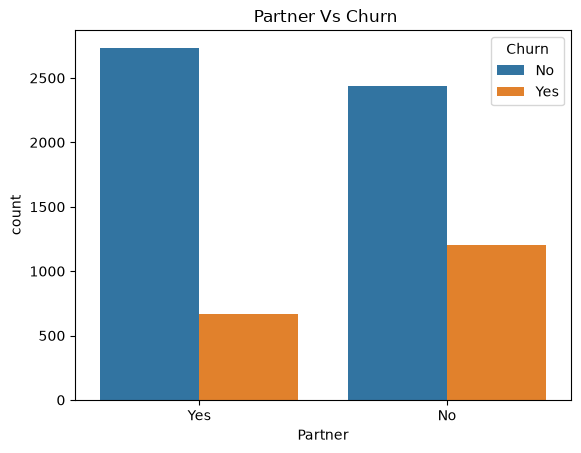

In [26]:
# viz
plt.title(' Partner Vs Churn')
sb.countplot(data = df , x= 'Partner',  hue='Churn')

In [29]:
# churn vs dependes

df.groupby(['Dependents'])['Churn'].value_counts()

Dependents  Churn
No          No       3390
            Yes      1543
Yes         No       1784
            Yes       326
Name: count, dtype: int64

<Axes: title={'center': 'Dependents VS Churn'}, xlabel='Dependents', ylabel='count'>

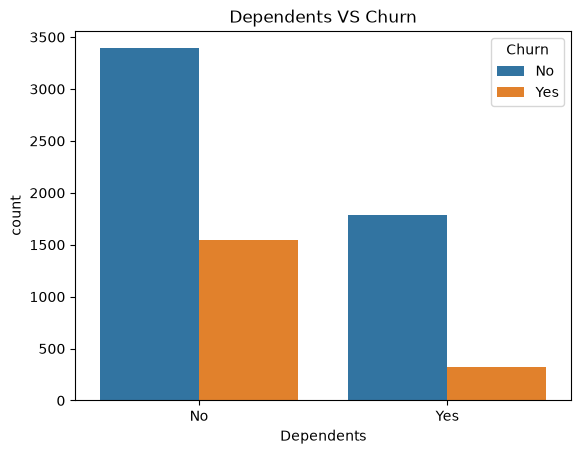

In [32]:
plt.title('Dependents VS Churn')
sb.countplot(x= df['Dependents'] ,  hue=df['Churn'])